# 📘 Capítulo 1: Funciones Elementales y Modelos Matemáticos
### Métodos Cuantitativos para la Economía — MSc. Jeel Cueva

---
> *"Un modelo matemático es una descripción matemática de un fenómeno del mundo real."*  
> — **James Stewart**, *Cálculo: Trascendentes tempranas*

---

**Contenido:** Funciones de costo, equilibrio de mercado, impuesto por unidad, break-even, modelo de telaraña, keynesiano, funciones cuadráticas, excedentes, interés compuesto, elasticidad.

In [1]:
# IMPORTACIONES Y CONFIGURACIÓN GLOBAL
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import fsolve

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.labelsize': 11, 'legend.fontsize': 10
})
C_AZUL='#1f77b4'; C_ROJO='#d62728'; C_VERDE='#2ca02c'
C_NARANJA='#ff7f0e'; C_MORADO='#9467bd'
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## Ejemplo 1.1 — Función de Costo Total
### $C(x) = 0.002x^2 + 5x + 200$ (miles de soles)

C(0)   = 200  → Costo fijo
C(100) = 720.0 miles de S/
C(1000)= 7,200.0 miles de S/
Costo marginal aprox. en x=1,000: 9.002 miles de S/


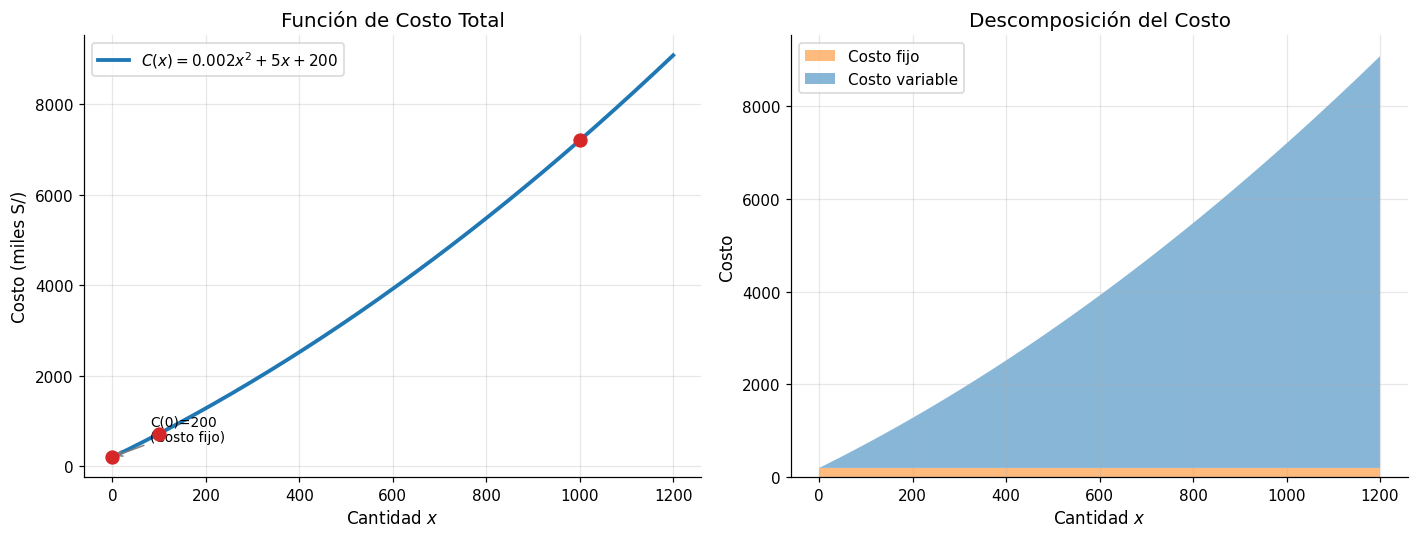

In [2]:
# EJEMPLO 1.1 — Función de costo total cuadrática
x = sp.Symbol('x', positive=True)
C = 0.002*x**2 + 5*x + 200

C0 = 200
C100 = float(C.subs(x, 100))
C1000 = float(C.subs(x, 1000))
C1001 = float(C.subs(x, 1001))
CMg_aprox = C1001 - C1000

print(f'C(0)   = {C0:,.0f}  → Costo fijo')
print(f'C(100) = {C100:,.1f} miles de S/')
print(f'C(1000)= {C1000:,.1f} miles de S/')
print(f'Costo marginal aprox. en x=1,000: {CMg_aprox:.3f} miles de S/')

x_v = np.linspace(0, 1200, 400)
C_v = 0.002*x_v**2 + 5*x_v + 200

fig, axes = plt.subplots(1, 2, figsize=(13,5))
ax = axes[0]
ax.plot(x_v, C_v, color=C_AZUL, lw=2.5, label='$C(x)=0.002x^2+5x+200$')
ax.scatter([0,100,1000],[200,C100,C1000], color=C_ROJO, s=70, zorder=5)
ax.annotate('C(0)=200\n(Costo fijo)', xy=(0,200), xytext=(80,550),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
ax.set_xlabel('Cantidad $x$'); ax.set_ylabel('Costo (miles S/)')
ax.set_title('Función de Costo Total'); ax.legend()

ax2 = axes[1]
fijo_v = np.full_like(x_v, 200)
var_v  = 5*x_v + 0.002*x_v**2
ax2.stackplot(x_v, fijo_v, var_v,
    labels=['Costo fijo','Costo variable'],
    colors=[C_NARANJA+'88', C_AZUL+'88'])
ax2.set_xlabel('Cantidad $x$'); ax2.set_ylabel('Costo')
ax2.set_title('Descomposición del Costo'); ax2.legend(loc='upper left')
plt.tight_layout(); plt.savefig('fig_c01_costo_total.png', bbox_inches='tight')
plt.show()

## Ejemplo 1.2 — Equilibrio de Mercado Lineal
### $Q_d = 200-4P$,  $Q_s = 50+6P$

Equilibrio: 200-4P = 50+6P → 150=10P
P* = 15,  Q* = 140


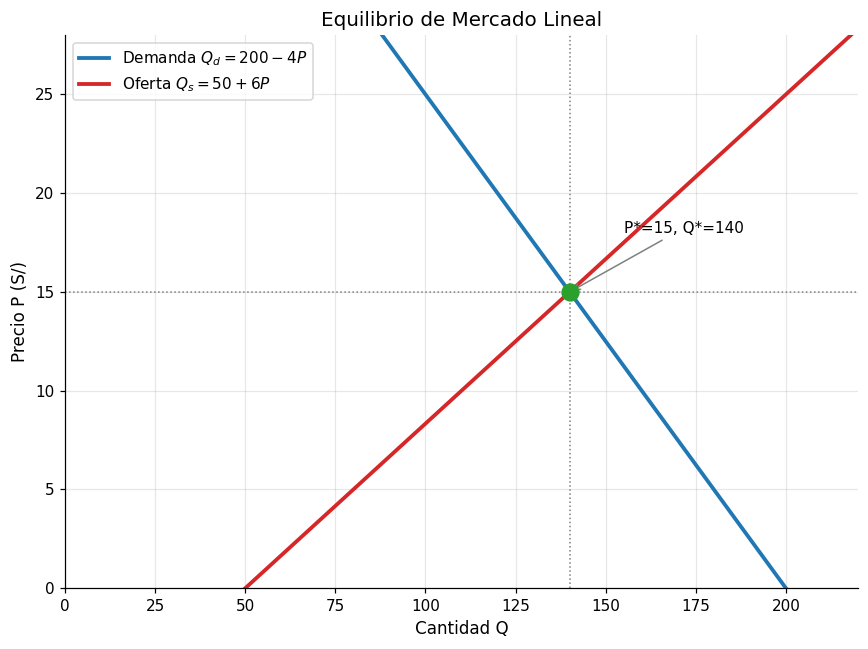

In [3]:
# EJEMPLO 1.2 — Equilibrio de mercado
P = sp.Symbol('P')
Qd = 200 - 4*P; Qs = 50 + 6*P
P_eq = sp.solve(Qd - Qs, P)[0]
Q_eq = Qd.subs(P, P_eq)
print(f'Equilibrio: 200-4P = 50+6P → 150=10P')
print(f'P* = {P_eq},  Q* = {Q_eq}')

P_v = np.linspace(0, 30, 200)
Qd_v = 200 - 4*P_v; Qs_v = 50 + 6*P_v

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(Qd_v, P_v, color=C_AZUL, lw=2.5, label='Demanda $Q_d=200-4P$')
ax.plot(Qs_v, P_v, color=C_ROJO,  lw=2.5, label='Oferta $Q_s=50+6P$')
ax.scatter([float(Q_eq)],[float(P_eq)], color=C_VERDE, s=120, zorder=6)
ax.annotate(f'P*={P_eq}, Q*={Q_eq}', xy=(float(Q_eq),float(P_eq)),
    xytext=(float(Q_eq)+15,float(P_eq)+3), fontsize=10,
    arrowprops=dict(arrowstyle='->', color='gray'))
ax.axhline(float(P_eq), color='gray', ls=':', lw=1)
ax.axvline(float(Q_eq), color='gray', ls=':', lw=1)
ax.set_xlabel('Cantidad Q'); ax.set_ylabel('Precio P (S/)')
ax.set_title('Equilibrio de Mercado Lineal'); ax.legend()
ax.set_xlim(0,220); ax.set_ylim(0,28)
plt.tight_layout(); plt.savefig('fig_c01_equilibrio.png', bbox_inches='tight')
plt.show()

## Ejemplo 1.3 — Impuesto por Unidad ($t=8$)
### $Q_d=300-5P$, $Q_s=40+3P$, $t=8$ S/unidad

Sin impuesto:  P*=65/2,   Q*=275/2
Con impuesto:  Pc=71/2,  Qt=245/2
Precio productor: Pp=55/2
Recaudación = 8×245/2 = 980


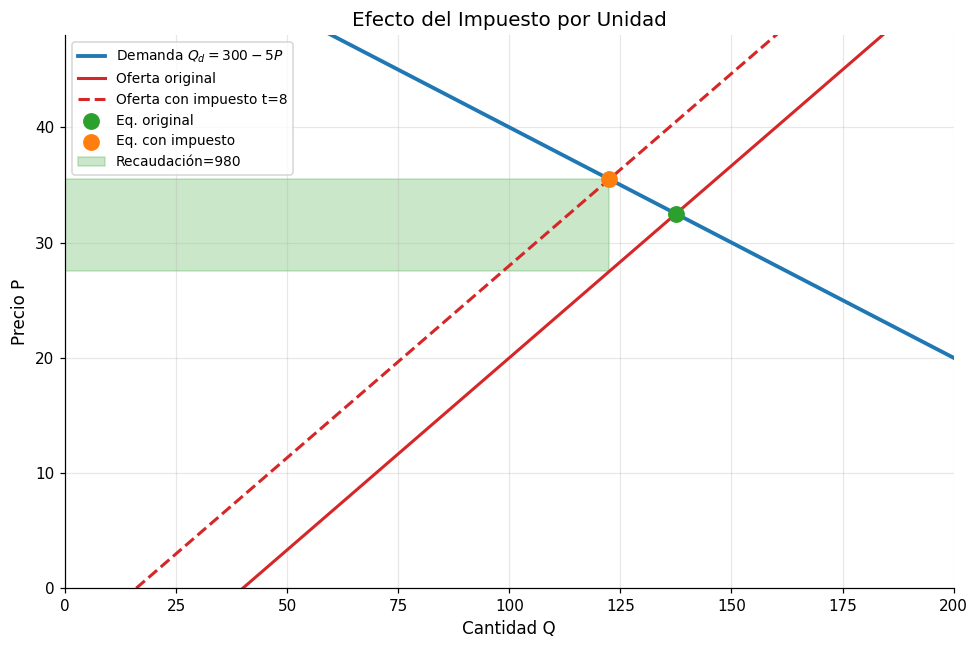

In [4]:
# EJEMPLO 1.3 — Equilibrio con impuesto
P = sp.Symbol('Pc')
t = 8
Qd0 = 300 - 5*P; Qs0 = 40 + 3*P
# Sin impuesto
P0 = sp.solve(Qd0 - Qs0, P)[0]
Q0 = Qd0.subs(P, P0)
# Con impuesto: oferta desplazada
Qs_t = 40 + 3*(P - t)
Pc = sp.solve(Qd0 - Qs_t, P)[0]
Qt = Qd0.subs(P, Pc)
Pp = Pc - t
recaud = t * Qt
print(f'Sin impuesto:  P*={P0},   Q*={Q0}')
print(f'Con impuesto:  Pc={Pc},  Qt={Qt}')
print(f'Precio productor: Pp={Pp}')
print(f'Recaudación = {t}×{Qt} = {recaud}')

Pc_v = np.linspace(0,50,300)
Qd_v = 300-5*Pc_v; Qs_v0 = 40+3*Pc_v; Qs_vt = 16+3*Pc_v

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(Qd_v, Pc_v, color=C_AZUL, lw=2.5, label='Demanda $Q_d=300-5P$')
ax.plot(Qs_v0, Pc_v, color=C_ROJO, lw=2, label='Oferta original')
ax.plot(Qs_vt, Pc_v, color=C_ROJO, lw=2, ls='--', label=f'Oferta con impuesto t={t}')
ax.scatter([float(Q0)],[float(P0)], color=C_VERDE, s=100, zorder=6, label='Eq. original')
ax.scatter([float(Qt)],[float(Pc)], color=C_NARANJA, s=100, zorder=6, label='Eq. con impuesto')
ax.fill_between([0,float(Qt)],[float(Pc),float(Pc)],[float(Pp),float(Pp)],
    alpha=0.25, color=C_VERDE, label=f'Recaudación={float(recaud):.0f}')
ax.set_xlabel('Cantidad Q'); ax.set_ylabel('Precio P')
ax.set_title('Efecto del Impuesto por Unidad')
ax.legend(fontsize=9); ax.set_xlim(0,200); ax.set_ylim(0,48)
plt.tight_layout(); plt.savefig('fig_c01_impuesto.png', bbox_inches='tight')
plt.show()

## Ejemplo 1.4 — Punto de Equilibrio (Break-Even)
### Precio=45, Costo variable=30, Costo fijo=6,000

I(q)=45q,  C(q)=30q+6000,  U(q)=15q-6000
Break-even: q*=400 unidades
En equilibrio: I=C=S/18,000
U(500) = S/1,500


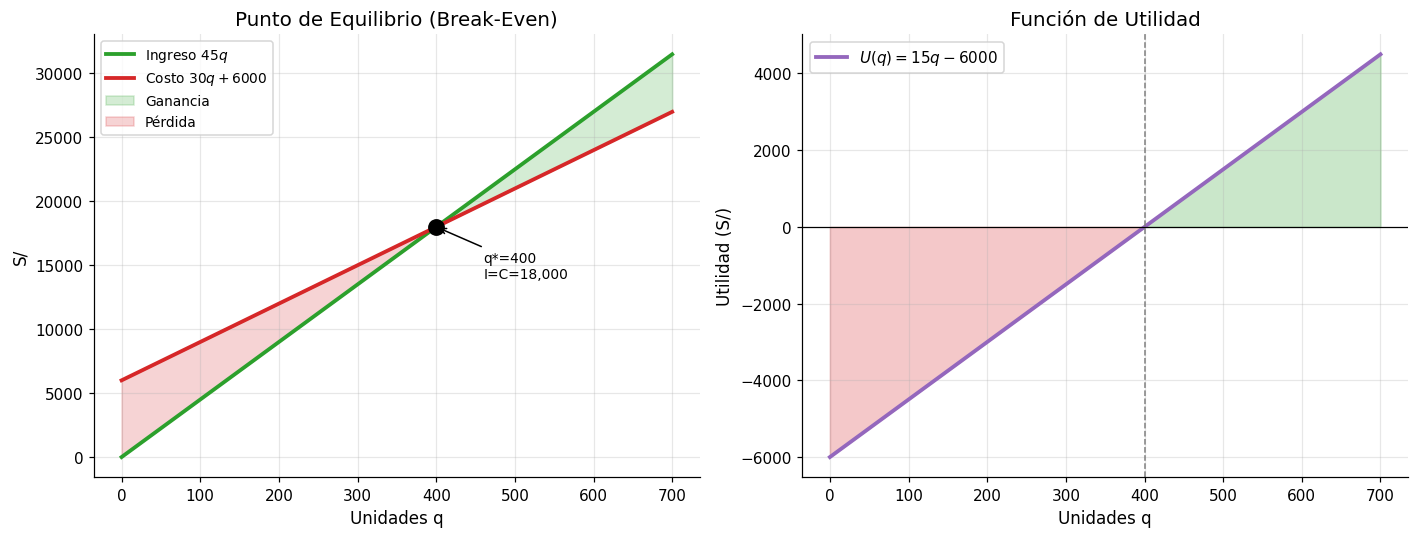

In [5]:
# EJEMPLO 1.4 — Punto de equilibrio (Break-Even)
pv, cv, CF = 45, 30, 6000
q_sym = sp.Symbol('q', positive=True)
I_s = pv*q_sym; C_s = cv*q_sym + CF; U_s = I_s - C_s
q_be = sp.solve(U_s, q_sym)[0]
I_be = float(I_s.subs(q_sym, q_be))
U500 = float(U_s.subs(q_sym, 500))
print(f'I(q)={pv}q,  C(q)={cv}q+{CF},  U(q)={pv-cv}q-{CF}')
print(f'Break-even: q*={q_be} unidades')
print(f'En equilibrio: I=C=S/{I_be:,.0f}')
print(f'U(500) = S/{U500:,.0f}')

q_v = np.linspace(0,700,300)
Iv = pv*q_v; Cv = cv*q_v+CF; Uv = Iv-Cv

fig, axes = plt.subplots(1,2,figsize=(13,5))
ax = axes[0]
ax.plot(q_v,Iv,color=C_VERDE,lw=2.5,label=f'Ingreso ${pv}q$')
ax.plot(q_v,Cv,color=C_ROJO,lw=2.5,label=f'Costo ${cv}q+{CF}$')
ax.scatter([float(q_be)],[I_be],color='black',s=100,zorder=6)
ax.annotate(f'q*={q_be:.0f}\nI=C={I_be:,.0f}',
    xy=(float(q_be),I_be),xytext=(float(q_be)+60,I_be-4000),
    fontsize=9,arrowprops=dict(arrowstyle='->',color='black'))
ax.fill_between(q_v,Iv,Cv,where=(q_v>=float(q_be)),alpha=0.2,color=C_VERDE,label='Ganancia')
ax.fill_between(q_v,Iv,Cv,where=(q_v<float(q_be)), alpha=0.2,color=C_ROJO,label='Pérdida')
ax.set_xlabel('Unidades q'); ax.set_ylabel('S/')
ax.set_title('Punto de Equilibrio (Break-Even)'); ax.legend(fontsize=9)

ax2 = axes[1]
ax2.plot(q_v,Uv,color=C_MORADO,lw=2.5,label='$U(q)=15q-6000$')
ax2.axhline(0,color='black',lw=0.8)
ax2.axvline(float(q_be),color='gray',ls='--',lw=1)
ax2.fill_between(q_v,Uv,0,where=(q_v>=float(q_be)),alpha=0.25,color=C_VERDE)
ax2.fill_between(q_v,Uv,0,where=(q_v<float(q_be)),alpha=0.25,color=C_ROJO)
ax2.set_xlabel('Unidades q'); ax2.set_ylabel('Utilidad (S/)')
ax2.set_title('Función de Utilidad'); ax2.legend()
plt.tight_layout(); plt.savefig('fig_c01_breakeven.png', bbox_inches='tight'); plt.show()

## Ejemplo 1.5 — Maximización del Beneficio Cuadrático
### $\pi(x) = -2x^2 + 100x - 500$

π(x) = -2x² + 100x - 500
Óptimo: x* = 25.0,  π(x*) = 750 miles de S/
Break-even puntos: x₁≈5.64, x₂≈44.36


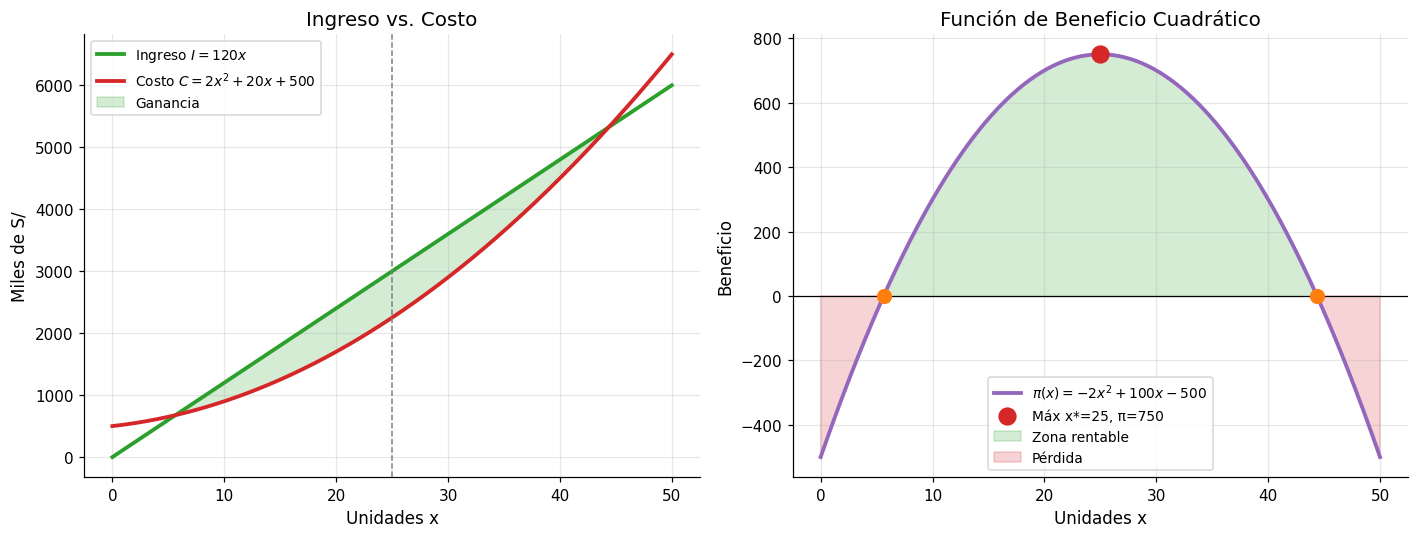

In [6]:
# EJEMPLO 1.5 — Beneficio cuadrático y optimización
x = sp.Symbol('x')
I_s = 120*x; C_s = 2*x**2 + 20*x + 500
pi_s = I_s - C_s  # = -2x² + 100x - 500
x_opt = 25.0
pi_max = float(pi_s.subs(x, x_opt))
raices = sp.solve(pi_s, x)
print(f'π(x) = -2x² + 100x - 500')
print(f'Óptimo: x* = {x_opt},  π(x*) = {pi_max:,.0f} miles de S/')
print(f'Break-even puntos: x₁≈{float(raices[0]):.2f}, x₂≈{float(raices[1]):.2f}')

x_v = np.linspace(0,50,300)
Iv = 120*x_v; Cv = 2*x_v**2+20*x_v+500
pi_v = Iv - Cv

fig, axes = plt.subplots(1,2,figsize=(13,5))
ax = axes[0]
ax.plot(x_v,Iv,color=C_VERDE,lw=2.5,label='Ingreso $I=120x$')
ax.plot(x_v,Cv,color=C_ROJO,lw=2.5,label='Costo $C=2x^2+20x+500$')
ax.axvline(x_opt,color='gray',ls='--',lw=1)
ax.fill_between(x_v,Iv,Cv,where=(Iv>Cv),alpha=0.2,color=C_VERDE,label='Ganancia')
ax.set_xlabel('Unidades x'); ax.set_ylabel('Miles de S/')
ax.set_title('Ingreso vs. Costo'); ax.legend(fontsize=9)

ax2 = axes[1]
ax2.plot(x_v,pi_v,color=C_MORADO,lw=2.5,label='$\\pi(x)=-2x^2+100x-500$')
ax2.axhline(0,color='black',lw=0.8)
ax2.scatter([x_opt],[pi_max],color=C_ROJO,s=120,zorder=6,label=f'Máx x*={x_opt:.0f}, π={pi_max:.0f}')
for r in raices:
    ax2.scatter([float(r)],[0],color=C_NARANJA,s=80,zorder=6)
ax2.fill_between(x_v,pi_v,0,where=(pi_v>0),alpha=0.2,color=C_VERDE,label='Zona rentable')
ax2.fill_between(x_v,pi_v,0,where=(pi_v<=0),alpha=0.2,color=C_ROJO,label='Pérdida')
ax2.set_xlabel('Unidades x'); ax2.set_ylabel('Beneficio')
ax2.set_title('Función de Beneficio Cuadrático'); ax2.legend(fontsize=9)
plt.tight_layout(); plt.savefig('fig_c01_beneficio.png',bbox_inches='tight'); plt.show()

## Ejemplo 1.6 — Excedente del Consumidor y Productor
### $D(p)=900-3p$, $O(p)=2p-100$

P* = 200,  Q* = 300
EC = 15,000
EP = 22,500
Bienestar total = 37,500


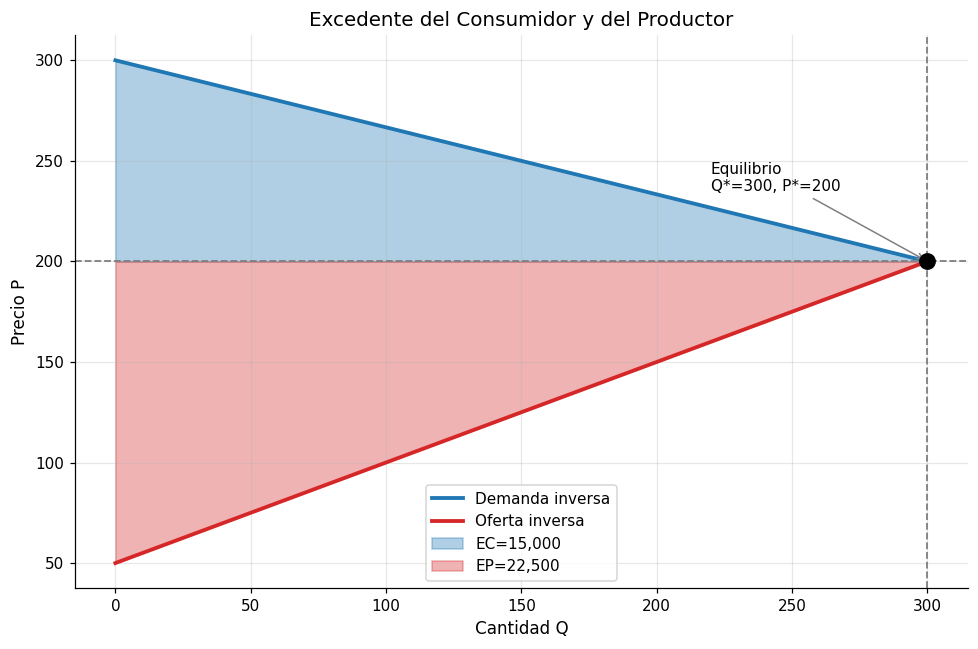

In [7]:
# EJEMPLO 1.6 — Excedentes del consumidor y productor
p = sp.Symbol('p')
Dp = 900-3*p; Op = 2*p-100
p_eq = float(sp.solve(Dp-Op,p)[0])
Q_eq = float(Dp.subs(p,p_eq))
a_dem = 300.0  # intercepto precio demanda
b_ofe = 50.0   # intercepto precio oferta
EC = 0.5*(a_dem-p_eq)*Q_eq
EP = 0.5*(p_eq-b_ofe)*Q_eq
print(f'P* = {p_eq:.0f},  Q* = {Q_eq:.0f}')
print(f'EC = {EC:,.0f}')
print(f'EP = {EP:,.0f}')
print(f'Bienestar total = {EC+EP:,.0f}')

Q_v = np.linspace(0, Q_eq, 200)
Pd_inv = (900-Q_v)/3   # demanda inversa
Po_inv = (Q_v+100)/2   # oferta inversa

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(Q_v, Pd_inv, color=C_AZUL, lw=2.5, label='Demanda inversa')
ax.plot(Q_v, Po_inv, color=C_ROJO,  lw=2.5, label='Oferta inversa')
ax.axhline(p_eq, color='gray', ls='--', lw=1.2)
ax.axvline(Q_eq, color='gray', ls='--', lw=1.2)
ax.fill_between(Q_v, Pd_inv, p_eq, alpha=0.35, color=C_AZUL, label=f'EC={EC:,.0f}')
ax.fill_between(Q_v, p_eq, Po_inv, alpha=0.35, color=C_ROJO, label=f'EP={EP:,.0f}')
ax.scatter([Q_eq],[p_eq],color='black',s=100,zorder=6)
ax.annotate(f'Equilibrio\nQ*={Q_eq:.0f}, P*={p_eq:.0f}',
    xy=(Q_eq,p_eq), xytext=(Q_eq-80,p_eq+35), fontsize=10,
    arrowprops=dict(arrowstyle='->',color='gray'))
ax.set_xlabel('Cantidad Q'); ax.set_ylabel('Precio P')
ax.set_title('Excedente del Consumidor y del Productor'); ax.legend()
plt.tight_layout(); plt.savefig('fig_c01_excedentes.png',bbox_inches='tight'); plt.show()

## Ejemplo 1.7 — Interés Compuesto Continuo
### $A(t) = 10{,}000 \cdot e^{0.06t}$

A(5)  continuo = S/13,498.59
A(10) continuo = S/18,221.19
A(10) anual    = S/17,908.48
Ventaja continua = S/312.71
Tiempo duplicación = ln(2)/0.06 = 11.55 años


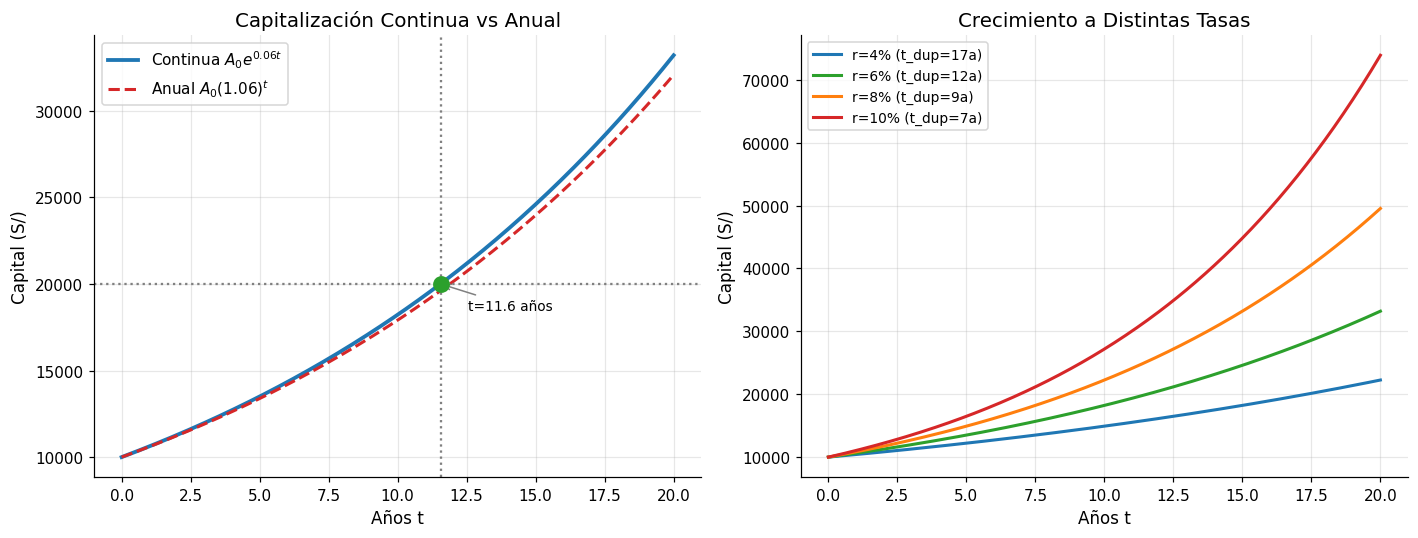

In [8]:
# EJEMPLO 1.7 — Capitalización continua y tiempo de duplicación
A0, r = 10000, 0.06
A5  = A0*np.exp(r*5)
A10c= A0*np.exp(r*10)
A10a= A0*(1+r)**10
t_dup = np.log(2)/r
print(f'A(5)  continuo = S/{A5:,.2f}')
print(f'A(10) continuo = S/{A10c:,.2f}')
print(f'A(10) anual    = S/{A10a:,.2f}')
print(f'Ventaja continua = S/{A10c-A10a:,.2f}')
print(f'Tiempo duplicación = ln(2)/{r} = {t_dup:.2f} años')

t_v = np.linspace(0,20,300)
A_c = A0*np.exp(r*t_v)
A_a = A0*(1+r)**t_v

fig, axes = plt.subplots(1,2,figsize=(13,5))
ax = axes[0]
ax.plot(t_v, A_c, color=C_AZUL, lw=2.5, label='Continua $A_0e^{0.06t}$')
ax.plot(t_v, A_a, color=C_ROJO, lw=2, ls='--', label='Anual $A_0(1.06)^t$')
ax.axvline(t_dup, color='gray', ls=':'); ax.axhline(2*A0, color='gray', ls=':')
ax.scatter([t_dup],[2*A0],color=C_VERDE,s=100,zorder=6)
ax.annotate(f't={t_dup:.1f} años',xy=(t_dup,2*A0),xytext=(t_dup+1,2*A0-1500),fontsize=9,
    arrowprops=dict(arrowstyle='->',color='gray'))
ax.set_xlabel('Años t'); ax.set_ylabel('Capital (S/)')
ax.set_title('Capitalización Continua vs Anual'); ax.legend()

ax2 = axes[1]
tasas=[0.04,0.06,0.08,0.10]; cols=[C_AZUL,C_VERDE,C_NARANJA,C_ROJO]
for tasa,col in zip(tasas,cols):
    ax2.plot(t_v, A0*np.exp(tasa*t_v), color=col, lw=2,
             label=f'r={tasa*100:.0f}% (t_dup={np.log(2)/tasa:.0f}a)')
ax2.set_xlabel('Años t'); ax2.set_ylabel('Capital (S/)')
ax2.set_title('Crecimiento a Distintas Tasas'); ax2.legend(fontsize=9)
plt.tight_layout(); plt.savefig('fig_c01_interes.png',bbox_inches='tight'); plt.show()

## Ejemplo 1.8 — Elasticidad Precio de la Demanda
### $Q = 200 - 5P$ y relación con el Ingreso Total

Elasticidad para Q = 200 - 5P
    P       Q       ε            Tipo
----------------------------------------
   10     150   -0.33      Inelástica
   15     125   -0.60      Inelástica
   20     100   -1.00        Unitaria
   25      75   -1.67        Elástica
   30      50   -3.00        Elástica
   35      25   -7.00        Elástica


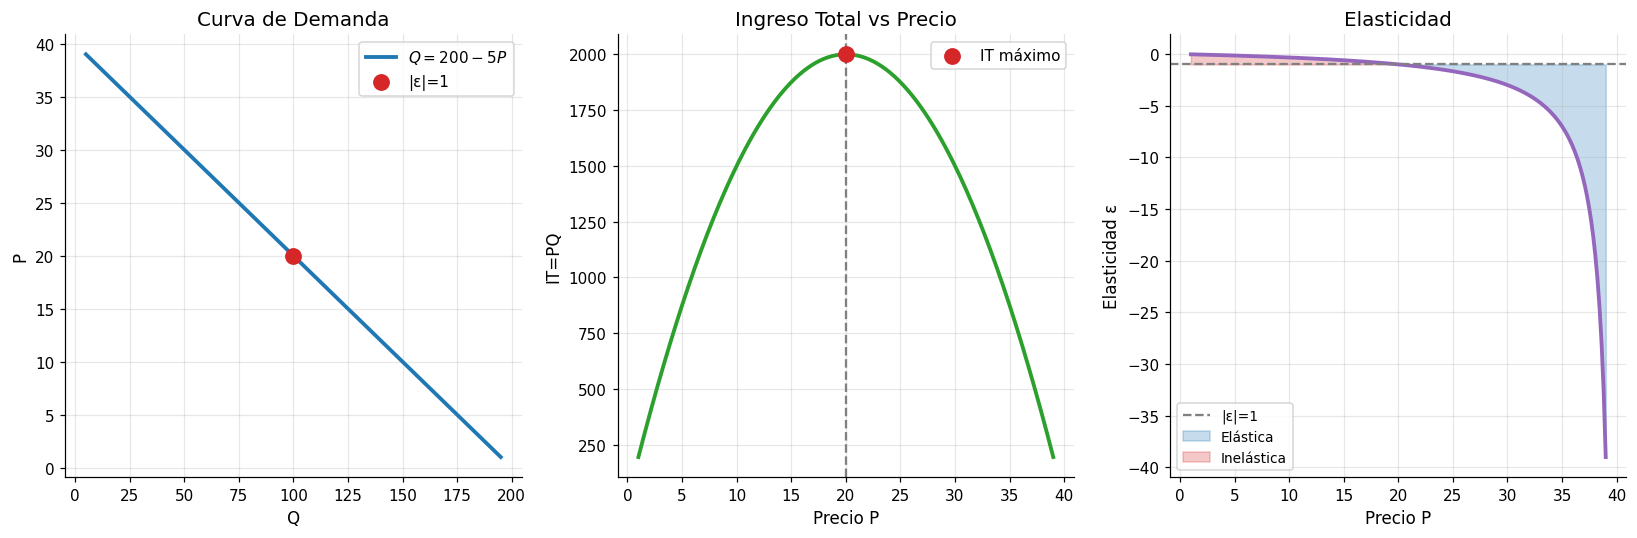

In [9]:
# EJEMPLO 1.8 — Elasticidad y estrategia de precios
print('Elasticidad para Q = 200 - 5P')
print(f'{"P":>5} {"Q":>7} {"ε":>7} {"Tipo":>15}')
print('-'*40)
for Pv in [10,15,20,25,30,35]:
    Qv = 200 - 5*Pv
    ev = -5*(Pv/Qv)
    tipo='Unitaria' if abs(abs(ev)-1)<0.01 else ('Elástica' if abs(ev)>1 else 'Inelástica')
    print(f'{Pv:>5} {Qv:>7} {ev:>7.2f} {tipo:>15}')

P_r = np.linspace(1,39,200)
Q_r = 200-5*P_r
IT  = P_r*Q_r
eps = -5*(P_r/Q_r)

fig, axes = plt.subplots(1,3,figsize=(15,5))
ax=axes[0]
ax.plot(Q_r,P_r,color=C_AZUL,lw=2.5,label='$Q=200-5P$')
ax.scatter([100],[20],color=C_ROJO,s=100,zorder=6,label='|ε|=1')
ax.set_xlabel('Q'); ax.set_ylabel('P'); ax.set_title('Curva de Demanda'); ax.legend()

ax2=axes[1]
ax2.plot(P_r,IT,color=C_VERDE,lw=2.5)
ax2.axvline(20,color='gray',ls='--')
ax2.scatter([20],[20*(200-5*20)],color=C_ROJO,s=100,zorder=6,label='IT máximo')
ax2.set_xlabel('Precio P'); ax2.set_ylabel('IT=PQ')
ax2.set_title('Ingreso Total vs Precio'); ax2.legend()

ax3=axes[2]
ax3.plot(P_r,eps,color=C_MORADO,lw=2.5)
ax3.axhline(-1,color='gray',ls='--',label='|ε|=1')
ax3.fill_between(P_r,eps,-1,where=(eps<-1),alpha=0.25,color=C_AZUL,label='Elástica')
ax3.fill_between(P_r,eps,-1,where=(eps>-1),alpha=0.25,color=C_ROJO,label='Inelástica')
ax3.set_xlabel('Precio P'); ax3.set_ylabel('Elasticidad ε')
ax3.set_title('Elasticidad'); ax3.legend(fontsize=9)
plt.tight_layout(); plt.savefig('fig_c01_elasticidad.png',bbox_inches='tight'); plt.show()

## Ejemplo 1.9 — Modelo Keynesiano de Ingreso Nacional
### $Y^* = (a+I_0+G_0)/(1-b)$,  $a=100$, $b=0.8$, $I_0=200$, $G_0=150$

Y* = (100+200+150)/(1-0.8) = 2250
Multiplicador = 1/(1-0.8) = 5
ΔG=100 → ΔY=500


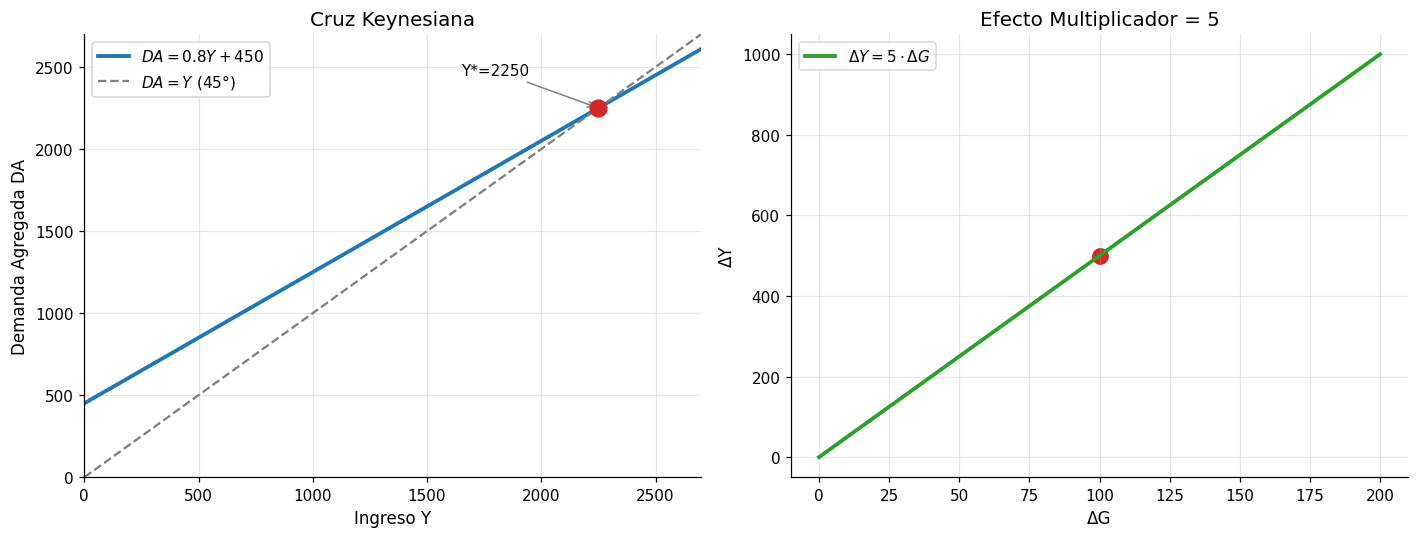

In [10]:
# EJEMPLO 1.9 — Cruz keynesiana y multiplicador fiscal
a,b,I0,G0 = 100, 0.8, 200, 150
Y_eq = (a+I0+G0)/(1-b)
mult = 1/(1-b)
print(f'Y* = ({a}+{I0}+{G0})/(1-{b}) = {Y_eq:.0f}')
print(f'Multiplicador = 1/(1-{b}) = {mult:.0f}')
print(f'ΔG=100 → ΔY={mult*100:.0f}')

Y_v = np.linspace(0,2700,300)
DA_v = a + b*Y_v + I0 + G0

fig, axes = plt.subplots(1,2,figsize=(13,5))
ax=axes[0]
ax.plot(Y_v,DA_v,color=C_AZUL,lw=2.5,label='$DA = 0.8Y+450$')
ax.plot(Y_v,Y_v,color='gray',ls='--',lw=1.5,label='$DA=Y$ (45°)')
ax.scatter([Y_eq],[Y_eq],color=C_ROJO,s=120,zorder=6)
ax.annotate(f'Y*={Y_eq:.0f}',xy=(Y_eq,Y_eq),
    xytext=(Y_eq-600,Y_eq+200),fontsize=10,
    arrowprops=dict(arrowstyle='->',color='gray'))
ax.set_xlabel('Ingreso Y'); ax.set_ylabel('Demanda Agregada DA')
ax.set_title('Cruz Keynesiana'); ax.legend()
ax.set_xlim(0,2700); ax.set_ylim(0,2700)

ax2=axes[1]
dG = np.linspace(0,200,100)
dY = mult*dG
ax2.plot(dG,dY,color=C_VERDE,lw=2.5,label=f'$\\Delta Y={mult:.0f}\\cdot\\Delta G$')
ax2.scatter([100],[mult*100],color=C_ROJO,s=100)
ax2.set_xlabel('ΔG'); ax2.set_ylabel('ΔY')
ax2.set_title(f'Efecto Multiplicador = {mult:.0f}'); ax2.legend()
plt.tight_layout(); plt.savefig('fig_c01_keynes.png',bbox_inches='tight'); plt.show()

---
## Resumen del Capítulo 1

| Concepto | Fórmula | Aplicación |
|---|---|---|
| Función lineal | $f(x)=mx+b$ | Costo variable, demanda simple |
| Equilibrio de mercado | $Q_d = Q_s$ | Precio y cantidad de equilibrio |
| Punto de equilibrio | $x^* = F/(p-v)$ | Break-even empresarial |
| Vértice parábola | $x_v = -b/(2a)$ | Maximización del beneficio |
| Excedente consumidor | $EC = \\frac{1}{2}(a-P^*)Q^*$ | Bienestar económico |
| Interés compuesto | $A(t) = A_0 e^{rt}$ | Finanzas y crecimiento |
| Elasticidad puntual | $\\varepsilon = \\frac{dQ}{dP}\\cdot\\frac{P}{Q}$ | Sensibilidad precio-cantidad |
| Modelo keynesiano | $Y^* = \\frac{a+I_0+G_0}{1-b}$ | Ingreso nacional |

---
*MSc. Jeel Cueva — UNHEVAL | UDH | UTP — Lima, 2025*